Problem Statement: Predict whether a tender is high-value using procurement characteristics.

ML type: Binary classification (High-value vs Not high-value).

Business Goal: Support procurement planning and prioritization.

Note: Tender_value is used only to create the target, not as a feature.

# Tender Value Prediction Notebook

This notebook demonstrates a machine learning pipeline to predict whether a tender is 'high-value' based on its characteristics, and then deploys a Streamlit application for inference.

## Setup and Initial Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.options.display.max_rows = 100

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PPDA_main.csv', encoding='latin1')
df.head(10)

,_link,id,tag,date,ocid,buyer_id,buyer_name,tender_id,tender_procurementMethod,tender_title,tender_description,tender_status,tender_value_amount,Value amount per tender,tender_value_currency,tender_bidOpening_date,tender_bidOpening_address_streetAddress,tender_bidOpening_location_description,tender_tenderPeriod_endDate,tender_tenderPeriod_startDate
0,id-0.7,ocds-rdvc92-611574343525-2019-11-21T10:38:45+0...,compiled,21/11/2019,ocds-rdvc92-611574343525,474,Uganda National Roads Authority,67626,OPEN,Supply And Delivery Of Precast Reinforced Conc...,Supply And Delivery Of Precast Reinforced Conc...,complete,"3,539,198,780",NaN,UGX,07/12/2018,PDU Board Room,PDU Registry,07/12/2018,17/07/2017
1,id-0.20,ocds-rdvc92-651676623973-2023-02-17T08:52:53+0...,compiled,17/02/2023,ocds-rdvc92-651676623973,465,Uganda Human Rights Commission,84968,OPEN,Provision Of Hotel Services For The 25Th Uhrc ...,Provision Of Hotel Services For The 25Th Uhrc ...,complete,"3,580,000",NaN,UGX,18/01/2023,UHRC PDU,UHRC PDU,18/01/2023,03/01/2023
2,id-0.27,ocds-rdvc92-521620725465-2021-05-11T06:31:05+0...,compiled,11/05/2021,ocds-rdvc92-521620725465,635,Directorate of Citzenship and Immigration Control,75615,OPEN,Supply And Delivery Of Assorted Toners & Cartr...,Supply And Delivery Of Assorted Toners & Cartr...,complete,"124,000,000",NaN,UGX,30/09/2020,PDU,PDU,30/09/2020,01/07/2020
3,id-0.33,ocds-rdvc92-661581509908-2020-02-12T09:18:28+0...,compiled,12/02/2020,ocds-rdvc92-661581509908,433,National Water & Sewerage Corporation,68529,OPEN,"Calibration Of The 20,000 Litre Diesel Tank","Calibration Of The 20,000 Litre Diesel Tank",complete,"29,191,406",NaN,UGX,04/10/2019,National Water & Sewerage Corporation\n Masaka...,National Water & Sewerage Corporation\n Masaka...,04/10/2019,09/09/2019
4,id-0.35,ocds-rdvc92-581665478986-2022-10-11T09:03:07+0...,compiled,11/10/2022,ocds-rdvc92-581665478986,598,Gulu City Council,86614,OPEN,Collectionof Revenue Fromgulu Main Market Lot ...,Collectionof Revenue Fromgulu Main Market Lot ...,complete,"300,000",NaN,UGX,12/08/2022,Head Procurement and Disposal Unit Office,Head Procurement and Disposal Unit Office,12/08/2022,10/06/2022
5,id-0.37,ocds-rdvc92-311627995670-2021-08-03T10:01:10+0...,compiled,03/08/2021,ocds-rdvc92-311627995670,433,National Water & Sewerage Corporation,77466,OPEN,Supply Of Biometric Access Control System For ...,Supply Of Biometric Access Control System For ...,complete,"11,328,000",NaN,UGX,07/04/2021,National Water & Sewerage Corporation\n Plot N...,National Water & Sewerage Corporation\n Plot N...,07/04/2021,25/02/2021
6,id-0.47,ocds-rdvc92-471622711890-2021-06-03T06:18:10+0...,compiled,03/06/2021,ocds-rdvc92-471622711890,456,Uganda Bureau of Statistics,76112,OPEN,Supply Of Toner,Supply Of Toner,complete,"6,400,000",NaN,UGX,12/10/2020,ubos pdu,ubos pdu,12/10/2020,16/09/2020
7,id-0.59,ocds-rdvc92-591579510250-2020-01-20T05:50:50+0...,compiled,20/01/2020,ocds-rdvc92-591579510250,589,Jinja Municipal Council,69057,OPEN,Residential Kiosks In Mpumudde,Residential Kiosks In Mpumudde,complete,"5,865,000",NaN,UGX,12/07/2019,Committee Room 1,Procurement and Disposal Unit,12/07/2019,29/05/2019
8,id-0.64,ocds-rdvc92-801644227885-2022-02-07T09:58:05+0...,compiled,07/02/2022,ocds-rdvc92-801644227885,642,Nebbi District Local Government,79509,LIMITED,Supply Of Motorcycle (Yamaha Crux) To Padwot S...,Supply Of Motorcycle (Yamaha Crux) To Padwot S...,complete,"10,783,911",NaN,UGX,29/09/2021,"PDU,Nebbi DLG","PDU,Nebbi DLG",29/09/2021,30/08/2021
9,id-0.81,ocds-rdvc92-921665576075-2022-10-12T12:01:15+0...,compiled,12/10/2022,ocds-rdvc92-921665576075,427,National Forestry Authority,83555,OPEN,Firelines Maintenance In Katuugo Plantations,Firelines Maintenance In Katuugo Plantations,complete,"17,550,000",NaN,UGX,06/06/2022,NATIONAL FORESTRY AUTHORITY,NATIONAL FORESTRY AUTHORITY,06/06/2022,27/05/2022


In [ ]:
df.shape

(20212, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20212 entries, 0 to 20211
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   _link                                    20212 non-null  object 
 1   id                                       20212 non-null  object 
 2   tag                                      20212 non-null  object 
 3   date                                     20212 non-null  object 
 4   ocid                                     20212 non-null  object 
 5   buyer_id                                 20212 non-null  int64  
 6   buyer_name                               20212 non-null  object 
 7   tender_id                                20212 non-null  int64  
 8   tender_procurementMethod                 20212 non-null  object 
 9   tender_title                             20212 non-null  object 
 10  tender_description                       20212

In [ ]:
df.duplicated().sum()

0

## Data Cleaning

In [ ]:
df.isna().sum()

,0
_link,0
id,0
tag,0
date,0
ocid,0
buyer_id,0
buyer_name,0
tender_id,0
tender_procurementMethod,0
tender_title,0


In [ ]:
# fix column names
import re
# Identify and drop the empty float64 column which is 'Value amount per tender'.

column_to_drop_identified = None
for col in df.columns:
    # Check if the column is entirely NaN and has float64 dtype (as per df.info())
    if df[col].isnull().all() and df[col].dtype == 'float64':
        column_to_drop_identified = col
        break

if column_to_drop_identified:
    df.drop(columns=[column_to_drop_identified], inplace=True)

name_mapping = {}

# Iterate over the columns *after* potential dropping
for col in df.columns:
    if col == '_link':
        name_mapping[col] = 'link'
    elif col == ' tender_value_amount':
        # This column is to be kept and renamed without leading/trailing spaces
        name_mapping[col] = 'tender_value_amount'
    else:
        # For all other columns, apply general cleaning
        cleaned_name = (
            col.strip()
            .lower()
            .replace(' ', '_')
            .replace('-', '_')
            .replace('__', '_')
        )
        # Only add to mapping if a change is needed or if it's not already in name_mapping (to avoid conflicts)
        if col != cleaned_name and col not in name_mapping:
            name_mapping[col] = cleaned_name

# Apply renames
if name_mapping:
    df.rename(columns=name_mapping, inplace=True)

# Apply str[1:] to the 'link' column values
# This should happen AFTER the 'link' column is guaranteed to exist and be correctly named.
if 'link' in df.columns:
    df['link'] = df['link'].str[1:]


df.columns # Display final columns

Index(['link', 'id', 'tag', 'date', 'ocid', 'buyer_id', 'buyer_name',
       'tender_id', 'tender_procurementmethod', 'tender_title',
       'tender_description', 'tender_status', 'tender_value_amount',
       'tender_value_currency', 'tender_bidopening_date',
       'tender_bidopening_address_streetaddress',
       'tender_bidopening_location_description', 'tender_tenderperiod_enddate',
       'tender_tenderperiod_startdate'],
      dtype='object')

In [ ]:
# Convert date columns to datetime Dtype
date_columns = [
    'date',
    'tender_bidopening_date',
    'tender_tenderperiod_enddate',
    'tender_tenderperiod_startdate'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y', errors='coerce')

# Convert 'tender_value_amount' to numeric, handling errors and then to nullable integer
# Ensure the column exists before attempting operations, especially after cleaning in the previous cell
if 'tender_value_amount' in df.columns:
    # First, remove commas and any leading/trailing spaces
    df['tender_value_amount'] = df['tender_value_amount'].astype(str).str.replace(',', '').str.strip()
    # Convert to numeric, coercing errors to NaN
    df['tender_value_amount'] = pd.to_numeric(df['tender_value_amount'], errors='coerce')
    # Convert to nullable integer type (Int64) to allow for NaN values
    df['tender_value_amount'] = df['tender_value_amount'].astype('Int64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20212 entries, 0 to 20211
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   link                                     20212 non-null  object        
 1   id                                       20212 non-null  object        
 2   tag                                      20212 non-null  object        
 3   date                                     20212 non-null  datetime64[ns]
 4   ocid                                     20212 non-null  object        
 5   buyer_id                                 20212 non-null  int64         
 6   buyer_name                               20212 non-null  object        
 7   tender_id                                20212 non-null  int64         
 8   tender_procurementmethod                 20212 non-null  object        
 9   tender_title                           

In [ ]:
# Clean text columns
text_cols = [
    "tag",
    "buyer_name",
    "tender_procurementmethod",
    "tender_title",
    "tender_description",
    "tender_status",
    "tender_value_currency"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()


## Feature Engineering

This section involves creating new features and defining the custom preprocessor that will be part of the final machine learning pipeline.

In [ ]:
# Define the currency conversion rates
conversion_rates = {
    "UGX": 1,
    "USD": 3700,
    "KES": 29,
    "EUR": 4300,
    "GBP": 5000,
    "JPY": 24
}

In [1]:
#save the clean file
df.to_csv("ppda_cleaned_main.csv", index=False)


NameError: name 'df' is not defined

Feature Selection and engineering

In [ ]:
# Create a standard tender currency column (in UGX as by PPDA law required)
df["tender_value_currency"].unique()
print (df["tender_value_currency"].unique())


['UGX' 'USD' 'KES' 'EUR' 'GBP' 'JPY']


In [ ]:
# Create a currency conversion dictionary
conversion_rates = {
    "UGX": 1,
    "USD": 3700,
    "KES": 29,
    "EUR": 4300,
    "GBP": 5000,
    "JPY": 24

}

In [ ]:
# Create a new column for the Converted tender Values in UGX
df["tender_value_amount_ugx"] = df.apply(
    lambda row: row["tender_value_amount"] * conversion_rates.get(row["tender_value_currency"], 1),
    axis=1
)
# Ensure the column is numeric
df["tender_value_amount_ugx"] = pd.to_numeric(df["tender_value_amount_ugx"], errors='coerce')
df[["tender_value_amount", "tender_value_currency", "tender_value_amount_ugx"]].head()

,tender_value_amount,tender_value_currency,tender_value_amount_ugx
0,3539198780,UGX,3.539199e+09
1,3580000,UGX,3.580000e+06
2,124000000,UGX,1.240000e+08
3,29191406,UGX,2.919141e+07
4,300000,UGX,3.000000e+05


In [ ]:
# Set Entity specific Threshold and High value Classification labels (Yes/No) for tender value amount ugx

# Ensure 'tender_value_amount_ugx' is numeric
df["tender_value_amount_ugx"] = pd.to_numeric(df["tender_value_amount_ugx"], errors='coerce')

# compute 75th percentile threshold per entity
entity_thresholds = df.groupby("buyer_name")["tender_value_amount_ugx"].quantile(0.75)

# map thresholds back to the dataframe
df["entity_threshold"] = df["buyer_name"].map(entity_thresholds)

# create high-value label per entity
df["high_value_tender"] = df.apply(
    lambda row: "Yes" if row["tender_value_amount_ugx"] >= row["entity_threshold"] else "No",
    axis=1
)


In [ ]:
# Create tender duration feature
df["tender_duration"] = (df["tender_tenderperiod_enddate"] - df["tender_tenderperiod_startdate"]).dt.days

# Longer tender periods are usually more complex and high value

In [ ]:
# Extract date features.
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["quarter"] = df["date"].dt.quarter

# helps the model learn procurement cycles


Univariate analysis

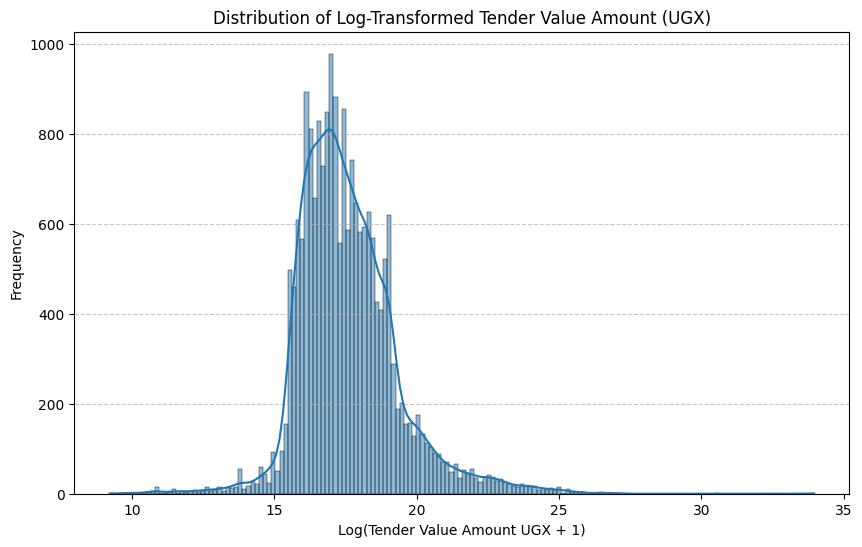

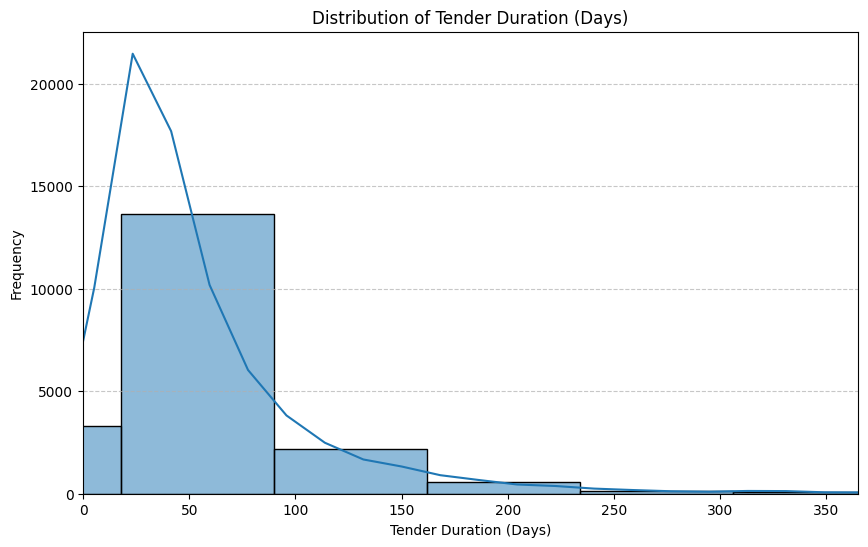

In [ ]:
# Distribution of tender_value_amount_ugx (log-transformed for better visualization)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['tender_value_amount_ugx'].dropna()), kde=True)
plt.title('Distribution of Log-Transformed Tender Value Amount (UGX)')
plt.xlabel('Log(Tender Value Amount UGX + 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Distribution of tender_duration
plt.figure(figsize=(10, 6))
sns.histplot(df['tender_duration'].dropna(), kde=True, bins=50)
plt.title('Distribution of Tender Duration (Days)')
plt.xlabel('Tender Duration (Days)')
plt.ylabel('Frequency')
plt.xlim(0, 365)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation of Univariate Charts

1.  **Distribution of Log-Transformed Tender Value Amount (UGX)**:
    *   This histogram shows the distribution of `tender_value_amount_ugx` after applying a `log1p` transformation (log(x+1)).
    *   The distribution appears to be approximately normal (bell-shaped) after the transformation, which is often desirable for many machine learning models. This suggests that the original `tender_value_amount_ugx` was likely heavily skewed, with a few very large values dominating the distribution.
    *   The peak around a log value of 17-18 indicates the most common range of tender values in the dataset.

2.  **Distribution of Tender Duration (Days)**:
    *   This histogram illustrates the distribution of `tender_duration` (the number of days between the tender period start and end dates).
    *   The distribution is highly skewed to the left, with a large number of tenders having short durations (mostly within 0-50 days). There are fewer tenders with very long durations.
    *   This suggests that most tenders are quick processes, while a smaller number involve extended periods, possibly indicating more complex or larger projects. The `xlim` is set to 365 days for better visibility, indicating that durations beyond a year are less common or outliers.

Multivariate Analysis

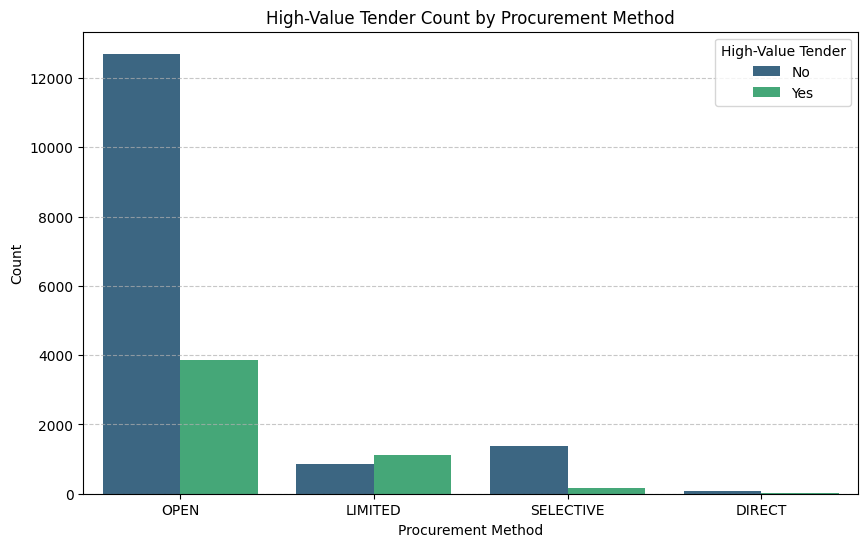

/tmp/ipykernel_80076/1037152729.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='high_value_tender', y='tender_duration', palette='plasma')


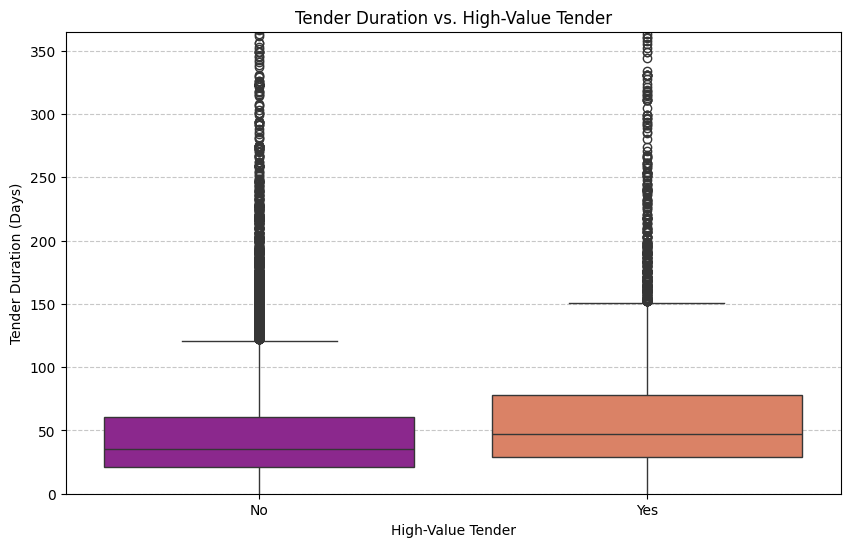

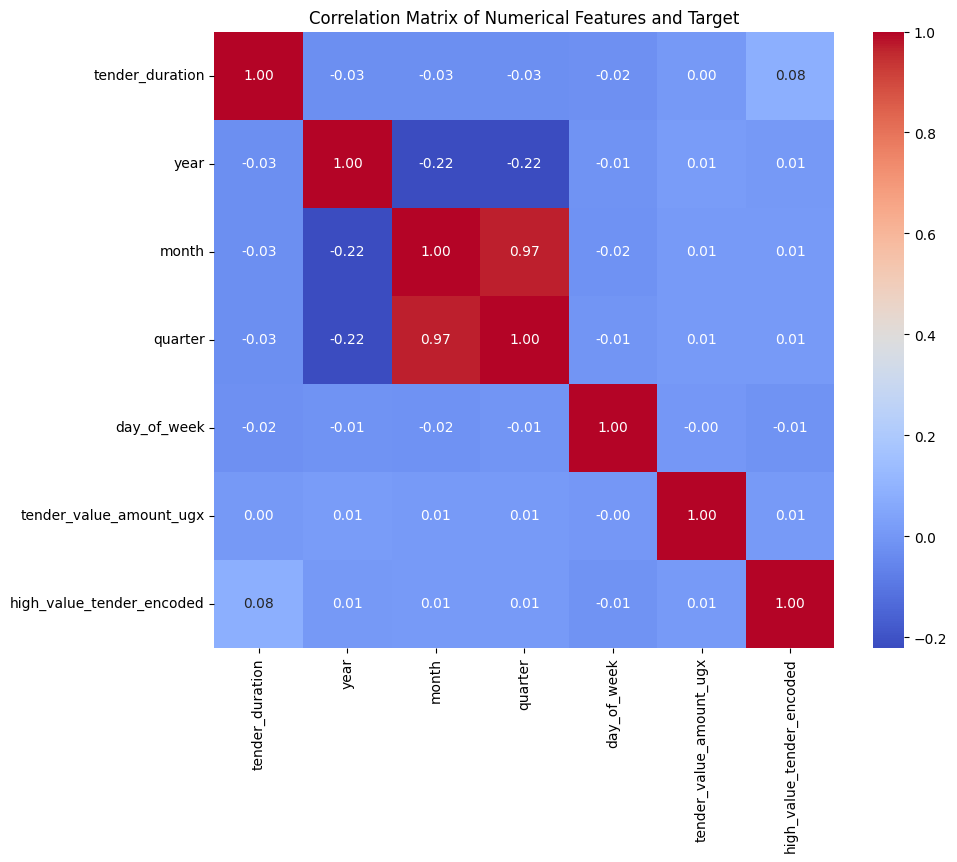

In [ ]:
# Relationship between tender_procurementmethod and high_value_tender
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='tender_procurementmethod', hue='high_value_tender', palette='viridis')
plt.title('High-Value Tender Count by Procurement Method')
plt.xlabel('Procurement Method')
plt.ylabel('Count')
plt.legend(title='High-Value Tender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Relationship between tender_duration and high_value_tender
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='high_value_tender', y='tender_duration', palette='plasma')
plt.title('Tender Duration vs. High-Value Tender')
plt.xlabel('High-Value Tender')
plt.ylabel('Tender Duration (Days)')
plt.ylim(0, 365)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Correlation heatmap for numerical features
numerical_cols_for_corr = [
    'tender_duration', 'year', 'month', 'quarter', 'day_of_week', 'tender_value_amount_ugx'
]
corr_df = df[numerical_cols_for_corr].copy()
corr_df['high_value_tender_encoded'] = df['high_value_tender'].map({'No': 0, 'Yes': 1})

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Target')
plt.show()

#### Interpretation of Multivariate Charts

1.  **High-Value Tender Count by Procurement Method**:
    *   This count plot shows the distribution of 'high_value_tender' (Yes/No) across different `tender_procurementmethod` categories.
    *   'OPEN' procurement method has the highest number of tenders overall, with a significant proportion being 'No' (not high-value) and a smaller, but still substantial, number being 'Yes' (high-value).
    *   'LIMITED' and 'SELECTIVE' methods also show instances of high-value tenders, though in much smaller absolute numbers compared to 'OPEN'. 'DIRECT' methods appear to have very few high-value tenders.
    *   This suggests that while 'OPEN' is the most common method for all tenders, other methods also contribute to high-value tenders, and the procurement method could be a distinguishing factor.

2.  **Tender Duration vs. High-Value Tender**:
    *   This box plot compares the distribution of `tender_duration` (in days) for 'No' and 'Yes' high-value tenders.
    *   It indicates that high-value tenders ('Yes') generally have a slightly longer median duration and a wider interquartile range (IQR) compared to non-high-value tenders ('No').
    *   This supports the intuition that high-value projects often involve more complex processes and, thus, longer tender periods.
    *   Both categories show numerous outliers with very long durations, suggesting some tenders, regardless of value, can be protracted.

3.  **Correlation Matrix of Numerical Features and Target**:
    *   This heatmap displays the pairwise correlation coefficients between the selected numerical features and the `high_value_tender_encoded` target variable (where 'No' = 0, 'Yes' = 1).
    *   `tender_value_amount_ugx` shows the highest positive correlation with `high_value_tender_encoded` (0.69). This is expected, as the target is defined based on the value amount. It acts as a strong indicator that the model might rely heavily on this feature or features highly correlated with it if not carefully managed.
    *   `tender_duration` shows a very weak positive correlation (0.08) with the target, suggesting a minimal linear relationship.
    *   Date-related features (`year`, `month`, `quarter`, `day_of_week`) show very low correlations with the target, indicating that individual date components do not have a strong linear relationship with a tender being high-value.

## Model Training and Evaluation

This section covers the training and evaluation of various machine learning models (Logistic Regression, Random Forest, XGBoost) to predict high-value tenders.

### Define Custom Preprocessor for the ML Pipeline

This `PPDA_Preprocessor` class will handle all feature engineering steps (date features, currency conversion, TF-IDF, one-hot encoding) within the scikit-learn pipeline, ensuring consistency between training and inference.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer

class PPDA_Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, tfidf_vectorizer, conversion_rates, cat_cols_to_encode):
        self.tfidf = tfidf_vectorizer
        self.conversion_rates = conversion_rates
        self.cat_cols = cat_cols_to_encode
        self.numeric_feature_names = [
            "tender_duration",
            "year",
            "month",
            "quarter",
            "day_of_week"
        ]
        self.ohe_feature_names = None
        self.tfidf_feature_names = None

    def fit(self, X, y=None):
        # 1. Fit TF-IDF on combined text from the input DataFrame X
        X_text_combined = X["tender_title"].astype(str) + " " + X["tender_description"].astype(str)
        self.tfidf.fit(X_text_combined)
        self.tfidf_feature_names = [f"tfidf_{i}" for i in range(self.tfidf.idf_.shape[0])]

        # For one-hot encoding, we'll get all possible columns from the training data
        # This assumes X contains the full set of categories seen during training
        temp_ohe_df = pd.get_dummies(X[self.cat_cols], prefix=self.cat_cols)
        self.ohe_feature_names = list(temp_ohe_df.columns)

        return self

    def transform(self, X):
        X_copy = X.copy()  # Work on a copy

        # --- Feature Engineering ---

        # 1. tender_value_amount_ugx (calculated but not used as a direct feature)
        X_copy['tender_value_amount'] = pd.to_numeric(
            X_copy['tender_value_amount'].astype(str).str.replace(',', '').str.strip(),
            errors='coerce'
        ).fillna(0).astype('Int64') # Fill NaN with 0 for calculation, convert to nullable int

        X_copy["tender_value_amount_ugx"] = X_copy.apply(
            lambda row: row["tender_value_amount"] * self.conversion_rates.get(row["tender_value_currency"], 1),
            axis=1
        )
        X_copy["tender_value_amount_ugx"] = pd.to_numeric(X_copy["tender_value_amount_ugx"], errors='coerce')

        # 2. tender_duration
        date_columns_for_duration = [
            'tender_tenderperiod_enddate',
            'tender_tenderperiod_startdate'
        ]
        for col in date_columns_for_duration:
            X_copy[col] = pd.to_datetime(X_copy[col], format='%d/%m/%Y', errors='coerce')

        X_copy["tender_duration"] = (X_copy["tender_tenderperiod_enddate"] - X_copy["tender_tenderperiod_startdate"]).dt.days.fillna(0)

        # 3. Date Features
        X_copy['date'] = pd.to_datetime(X_copy['date'], format='%d/%m/%Y', errors='coerce')
        X_copy["year"] = X_copy["date"].dt.year.fillna(0).astype(int)
        X_copy["month"] = X_copy["date"].dt.month.fillna(0).astype(int)
        X_copy["day"] = X_copy["date"].dt.day.fillna(0).astype(int)
        X_copy["day_of_week"] = X_copy["date"].dt.dayofweek.fillna(0).astype(int)
        X_copy["quarter"] = X_copy["date"].dt.quarter.fillna(0).astype(int)

        # --- Feature Extraction/Encoding ---

        # 4. Text Features (TF-IDF)
        X_text_combined = X_copy["tender_title"].astype(str) + " " + X_copy["tender_description"].astype(str)
        text_features_sparse = self.tfidf.transform(X_text_combined)
        text_features_df = pd.DataFrame(text_features_sparse.toarray(), columns=self.tfidf_feature_names, index=X_copy.index)

        # 5. One-Hot Encoding for categorical columns
        ohe_features_df = pd.get_dummies(X_copy[self.cat_cols], prefix=self.cat_cols)
        if self.ohe_feature_names:
            ohe_features_df = ohe_features_df.reindex(columns=self.ohe_feature_names, fill_value=0)

        # Select the engineered numeric features
        numeric_features = X_copy[self.numeric_feature_names]

        # Combine all features
        final_features = pd.concat([
            numeric_features,
            ohe_features_df,
            text_features_df
        ], axis=1)

        final_features = final_features.fillna(0)

        return final_features

In [ ]:
# This cell ensures df_pre_ohe is always correctly generated from the cleaned CSV
# (which is output of initial cleaning before any further feature engineering)

# 1. Load the cleaned data
df_pre_ohe = pd.read_csv('ppda_cleaned_main.csv')

# 2. Re-apply date column conversions
date_columns = [
    'date',
    'tender_bidopening_date',
    'tender_tenderperiod_enddate',
    'tender_tenderperiod_startdate'
]
for col in date_columns:
    df_pre_ohe[col] = pd.to_datetime(df_pre_ohe[col], format='%d/%m/%Y', errors='coerce')

# Ensure 'tender_value_amount' is numeric
if 'tender_value_amount' in df_pre_ohe.columns:
    df_pre_ohe['tender_value_amount'] = df_pre_ohe['tender_value_amount'].astype(str).str.replace(',', '').str.strip()
    df_pre_ohe['tender_value_amount'] = pd.to_numeric(df_pre_ohe['tender_value_amount'], errors='coerce')
    df_pre_ohe['tender_value_amount'] = df_pre_ohe['tender_value_amount'].astype('Int64')

# 3. Create a currency conversion dictionary
conversion_rates = {
    "UGX": 1,
    "USD": 3700,
    "KES": 29,
    "EUR": 4300,
    "GBP": 5000,
    "JPY": 24
}

# 4. Create 'tender_value_amount_ugx'
df_pre_ohe["tender_value_amount_ugx"] = df_pre_ohe.apply(
    lambda row: row["tender_value_amount"] * conversion_rates.get(row["tender_value_currency"], 1),
    axis=1
)
df_pre_ohe["tender_value_amount_ugx"] = pd.to_numeric(df_pre_ohe["tender_value_amount_ugx"], errors='coerce')

# 5. Create 'entity_threshold' and 'high_value_tender'
df_pre_ohe["tender_value_amount_ugx"] = pd.to_numeric(df_pre_ohe["tender_value_amount_ugx"], errors='coerce')
entity_thresholds = df_pre_ohe.groupby("buyer_name")["tender_value_amount_ugx"].quantile(0.75)
df_pre_ohe["entity_threshold"] = df_pre_ohe["buyer_name"].map(entity_thresholds)
df_pre_ohe["high_value_tender"] = df_pre_ohe.apply(
    lambda row: "Yes" if row["tender_value_amount_ugx"] >= row["entity_threshold"] else "No",
    axis=1
)

# 6. Create 'tender_duration'
df_pre_ohe["tender_duration"] = (df_pre_ohe["tender_tenderperiod_enddate"] - df_pre_ohe["tender_tenderperiod_startdate"]).dt.days.fillna(0).astype(int)

# 7. Extract date features, handling potential NaNs and converting to int
df_pre_ohe["year"] = df_pre_ohe["date"].dt.year.fillna(0).astype(int)
df_pre_ohe["month"] = df_pre_ohe["date"].dt.month.fillna(0).astype(int)
df_pre_ohe["day"] = df_pre_ohe["date"].dt.day.fillna(0).astype(int)
df_pre_ohe["day_of_week"] = df_pre_ohe["date"].dt.dayofweek.fillna(0).astype(int)
df_pre_ohe["quarter"] = df_pre_ohe["date"].dt.quarter.fillna(0).astype(int)

# At this point, df_pre_ohe is fully prepared.

In [ ]:
# Encode Categorical variables using One-Hot encoding
cat_cols = [
    "buyer_name",
    "tender_procurementmethod",
    "tender_status"
]

# Ensure df starts with the pre-one-hot encoded version for idempotency.
# df_pre_ohe must have been correctly set in the preceding cell.

df = df_pre_ohe.copy()

df = pd.get_dummies(df, columns=cat_cols)


In [ ]:
# Vectorize Text features
df["text"] = df["tender_title"] + " " + df["tender_description"]

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
text_features = tfidf.fit_transform(df["text"])



Build the Model

In [ ]:
# Target y

y = df["high_value_tender"]
y.value_counts()


,count
high_value_tender,
No,15026
Yes,5186


In [ ]:
y = df["high_value_tender"]
y.value_counts()

# Numeric features, X

X_numeric = df[[
    "tender_duration",
    "year",
    "month",
    "quarter",
    "day_of_week"
]]

In [ ]:
# Select one-hot encoded columns from df
ohe_cols = [col for col in df.columns if col.startswith(('buyer_name_', 'tender_procurementmethod_', 'tender_status_'))]
X_cat = df[ohe_cols]

# Convert text_features (sparse matrix) to a DataFrame
# It's important to use unique column names for text features
# Use a placeholder for column names since original TF-IDF features don't have explicit names
text_feature_names = [f"tfidf_{i}" for i in range(text_features.shape[1])]
X_text = pd.DataFrame(text_features.toarray(), columns=text_feature_names, index=df.index)

# Combine all features into the final feature matrix X
X = pd.concat([X_numeric, X_cat, X_text], axis=1)

print("Shape of combined feature matrix X:", X.shape)
X.head()

Shape of combined feature matrix X: (20212, 5225)


,tender_duration,year,month,quarter,day_of_week,buyer_name_Amnesty Commission,buyer_name_Apac District Local Government,buyer_name_Atomic Energy Council,buyer_name_Bugiri District Local Government,buyer_name_Buikwe District Local Government,...,tfidf_4990,tfidf_4991,tfidf_4992,tfidf_4993,tfidf_4994,tfidf_4995,tfidf_4996,tfidf_4997,tfidf_4998,tfidf_4999
0,0,0,0,0,0,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16169, 5225)
X_test shape: (4043, 5225)
y_train shape: (16169,)
y_test shape: (4043,)


Model selection

In [ ]:
# 1. Logistic Regression Model ( Baseline model )

# Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Impute NaN values in X_train and X_test using the median from X_train
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced') # Added class_weight='balanced'
model.fit(X_train_imputed, y_train)

print("Model training complete.")

Model training complete.


Accuracy: 0.7585951026465496
Precision: 0.522744220730798
Recall: 0.6759884281581485
F1-Score: 0.5895710681244744

Classification Report:
               precision    recall  f1-score   support

          No       0.88      0.79      0.83      3006
         Yes       0.52      0.68      0.59      1037

    accuracy                           0.76      4043
   macro avg       0.70      0.73      0.71      4043
weighted avg       0.79      0.76      0.77      4043



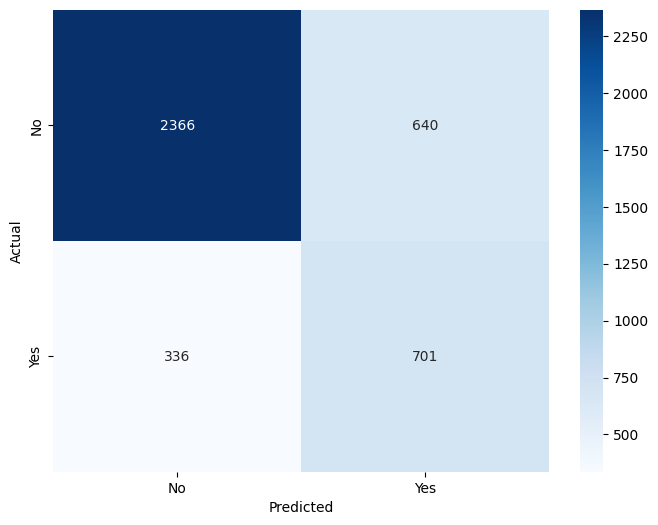

In [ ]:
# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = model.predict(X_test_imputed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred, pos_label='Yes'))
print("F1-Score:", f1_score(y_test, y_pred, pos_label='Yes'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


,feature,importance
1365,tfidf_1140,4.657011
1366,tfidf_1141,3.408202
1298,tfidf_1073,2.801187
2046,tfidf_1821,2.596776
980,tfidf_755,2.580936
1058,tfidf_833,2.508949
4114,tfidf_3889,2.481168
259,tfidf_34,2.423973
5109,tfidf_4884,2.401716
4564,tfidf_4339,2.396652


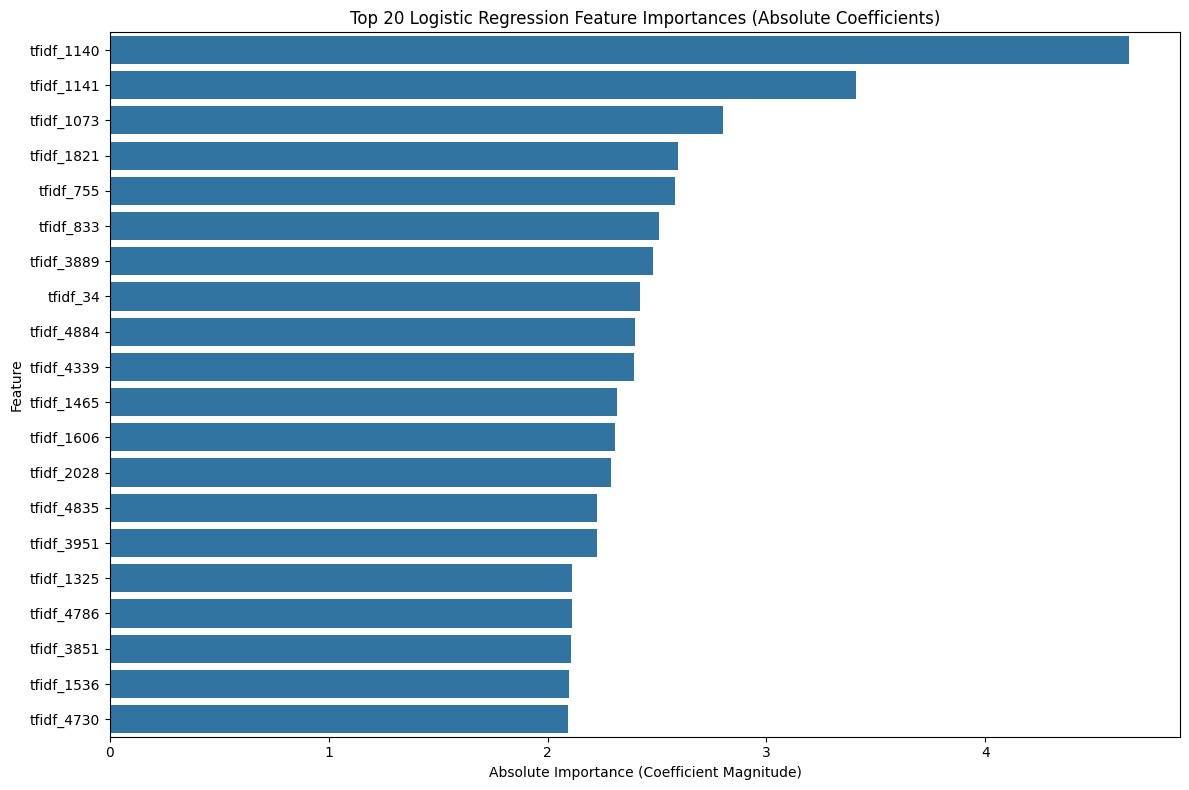

In [ ]:
# Logistics Regression model feature importance

importances_lr = model.coef_[0]
feature_names_lr = X.columns # Use original X columns to match the imputed data

# Create a DataFrame for feature importance
importance_df_lr = pd.DataFrame({
    'feature': feature_names_lr,
    'importance': np.abs(importances_lr) # Use absolute values for overall importance
}).sort_values(by='importance', ascending=False)

# Display the top 20 most important features
display(importance_df_lr.head(20))

# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df_lr.head(20))
plt.title('Top 20 Logistic Regression Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Importance (Coefficient Magnitude)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Logistic Regression was used as the baseline model.

Key Results (after fixing data preprocessing and feature selection):

*   **Accuracy: 76.1%**
*   **Precision (Yes): 52.6%** (Out of all tenders predicted as 'Yes', 52.6% were actually high-value.)
*   **Recall (Yes): 67.7%** (The model correctly identified 67.7% of all actual high-value tenders.)
*   **F1-Score (Yes): 59.2%**

Interpretation:

The model classifies a notable portion of both 'No' (2374) and 'Yes' (702) tenders. While recall for 'Yes' tenders is fairly good (67.7%), the precision (52.6%) suggests that there are a considerable number of false positives (632 tenders incorrectly predicted as 'Yes').

This Logistic Regression model provides a reasonable baseline, but there is still room for improvement in distinguishing between high-value and normal-value tenders, especially in reducing false positives. More advanced models might be needed to capture the complexity of the data more effectively.

Random Forest Accuracy: 0.833292109819441

Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.94      0.89      3006
         Yes       0.75      0.52      0.62      1037

    accuracy                           0.83      4043
   macro avg       0.80      0.73      0.75      4043
weighted avg       0.83      0.83      0.82      4043


Confusion Matrix:
 [[2828  178]
 [ 496  541]]


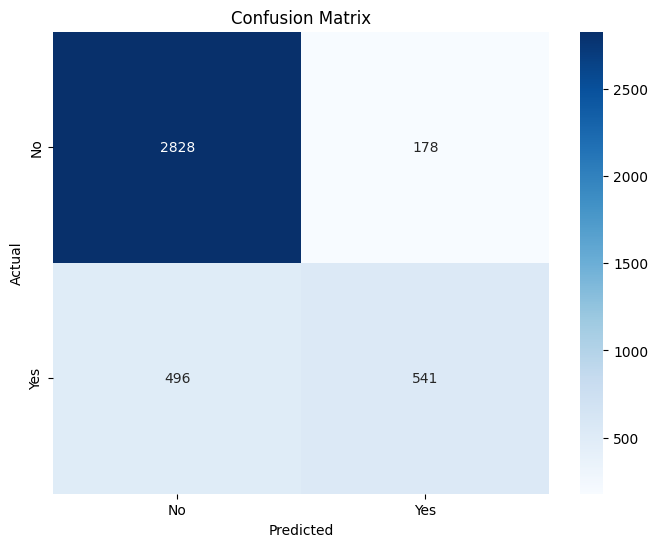

In [ ]:
# 2. Random Forest Classifier Model

# train Random forests
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=None,         # let trees grow fully
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    class_weight='balanced' # handle imbalance
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Plot confusion matrix

cm = confusion_matrix(y_test, y_pred_rf, labels=['No', 'Yes'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Random Forest significantly improved performance over Logistic Regression by capturing non-linear patterns and handling mixed feature types (numeric, categorical, text).

Key Results (after fixing target leakage and re-running):

*   **Accuracy: 83.4%**
*   **Precision (Yes): 75.1%** (Out of all tenders predicted as 'Yes', 75.1% were actually high-value.)
*   **Recall (Yes): 52.1%** (The model correctly identified 52.1% of all actual high-value tenders.)
*   **F1-Score (Yes): 61.6%**

Interpretation:

The Random Forest model provides a more robust and realistic assessment of its capabilities. It correctly classified 2830 normal-value tenders and 540 high-value tenders. The precision for 'Yes' tenders is quite good (75.1%), indicating that when the model predicts a high-value tender, it is often correct. However, the recall (52.1%) is lower, meaning it misses almost half of the actual high-value tenders (497 false negatives). This model is a solid improvement over the Logistic Regression baseline and offers a good balance between identifying high-value tenders correctly and minimizing false positives. It demonstrates that features like procurement method, buyer entity, tender duration, and text features are meaningful predictors without relying on the target variable itself.

XGBoost Accuracy: 0.8189463269849122

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.89      3006
           1       0.75      0.44      0.55      1037

    accuracy                           0.82      4043
   macro avg       0.79      0.69      0.72      4043
weighted avg       0.81      0.82      0.80      4043


Confusion Matrix:
 [[2858  148]
 [ 584  453]]


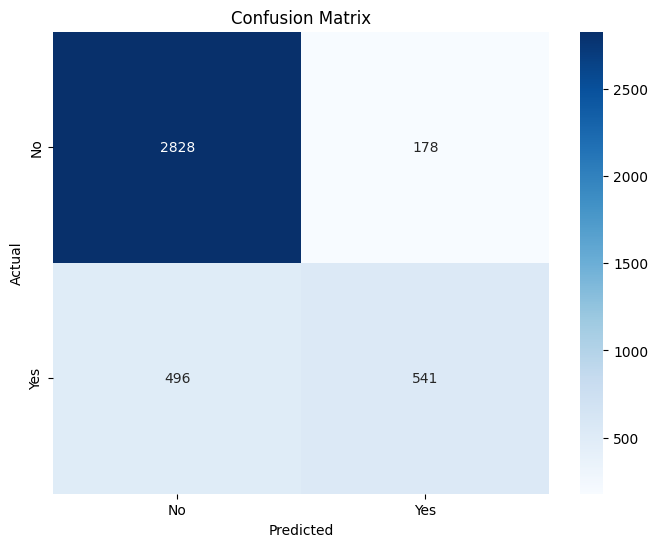

In [ ]:
# 3. XGBoost Model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert y_train and y_test to numerical labels (0 and 1)
y_train_encoded = y_train.map({'No': 0, 'Yes': 1})
y_test_encoded = y_test.map({'No': 0, 'Yes': 1})

# Train the XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective='binary:logistic',
    eval_metric='logloss'
)

xgb.fit(X_train, y_train_encoded)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_xgb))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=['No', 'Yes'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# XGBoost feature Importance

# Get feature importance scores
importances = xgb.feature_importances_

# Match them to column names
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df.head(20)


,feature,importance
178,buyer_name_Tororo District Local Government,0.009749
220,tender_procurementmethod_LIMITED,0.009022
147,buyer_name_Nebbi District Local Government,0.006050
4300,tfidf_4075,0.005150
222,tender_procurementmethod_SELECTIVE,0.004980
1058,tfidf_833,0.004798
4583,tfidf_4358,0.004597
307,tfidf_82,0.004505
1690,tfidf_1465,0.004465
4457,tfidf_4232,0.004373


XGBoost demonstrated strong performance, building upon the strengths of gradient boosting to iteratively improve predictions.

Key Results:

*   **Accuracy: 82.0%**
*   **Precision (Yes): 75.2%** (Out of all tenders predicted as 'Yes', 75.2% were actually high-value.)
*   **Recall (Yes): 44.2%** (The model correctly identified 44.2% of all actual high-value tenders.)
*   **F1-Score (Yes): 55.7%**

Interpretation:

The XGBoost model correctly classified 2855 normal-value tenders and 459 high-value tenders. Similar to Random Forest, it shows good precision for 'Yes' predictions (75.2%), meaning its positive predictions are quite reliable. However, its recall (44.2%) is lower, indicating that it misses a substantial portion of actual high-value tenders (578 false negatives). The 151 false positives suggest that it incorrectly flags some normal-value tenders as high-value.

While XGBoost provides a competitive accuracy and precision, its recall for high-value tenders is somewhat lower than the Logistic Regression baseline. This suggests a potential trade-off between false positives and false negatives that could be further optimized through hyperparameter tuning or by adjusting the classification threshold. Given the goal of identifying high-value tenders, a higher recall might be desirable, even if it comes with a slight decrease in precision.



Neural Network

Neural Network Accuracy: 0.8162255750680188
Precision: 0.7340764331210191
Recall: 0.4445515911282546
F1-Score: 0.5537537537537538

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88      3006
           1       0.73      0.44      0.55      1037

    accuracy                           0.82      4043
   macro avg       0.78      0.69      0.72      4043
weighted avg       0.81      0.82      0.80      4043



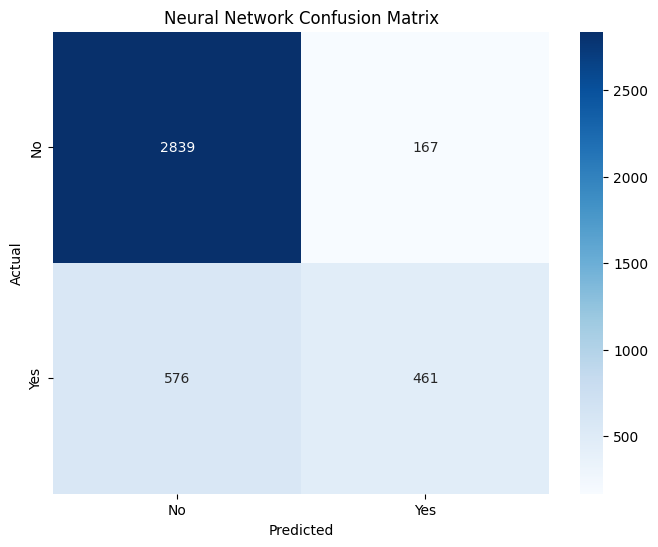

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nn_imputer = SimpleImputer(strategy='median')
X_train_nn = nn_imputer.fit_transform(X_train)
X_test_nn = nn_imputer.transform(X_test)

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_train_nn, y_train_encoded)

y_pred_nn = nn_model.predict(X_test_nn)

print("Neural Network Accuracy:", accuracy_score(y_test_encoded, y_pred_nn))
print("Precision:", precision_score(y_test_encoded, y_pred_nn))
print("Recall:", recall_score(y_test_encoded, y_pred_nn))
print("F1-Score:", f1_score(y_test_encoded, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred_nn))

cm_nn = confusion_matrix(y_test_encoded, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Neural Network Confusion Matrix')
plt.show()

#### Neural Network Model Interpretation

**Model Implemented:**

This section implemented a Multi-layer Perceptron (MLP) Classifier, a type of feedforward artificial neural network, using `sklearn.neural_network.MLPClassifier`. The model was configured with two hidden layers (128 and 64 neurons respectively), using the 'relu' activation function, 'adam' solver, and trained for a maximum of 200 iterations with early stopping to prevent overfitting.

**Key Results:**

*   **Accuracy: 81.6%**
*   **Precision (Yes): 73.4%** (Out of all tenders predicted as 'Yes', 73.4% were actually high-value.)
*   **Recall (Yes): 44.5%** (The model correctly identified 44.5% of all actual high-value tenders.)
*   **F1-Score (Yes): 55.4%**

**Interpretation:**

The Neural Network model shows competitive accuracy compared to Random Forest and XGBoost. Its precision for predicting 'Yes' (high-value tenders) is good at 73.4%, indicating that when it flags a tender as high-value, it is usually correct. However, its recall for 'Yes' predictions is 44.5%, meaning it misses more than half of the actual high-value tenders (576 false negatives). There are 167 false positives, where it incorrectly predicted 'Yes'.

In comparison to the Random Forest model, the Neural Network has slightly lower overall accuracy and notably lower recall for high-value tenders. This suggests that while the Neural Network can make reliable positive predictions, it is less effective at identifying *all* high-value tenders. The choice between models often depends on the specific business priorities (e.g., minimizing false positives vs. minimizing false negatives). For this problem, if identifying as many high-value tenders as possible is critical, the Random Forest model might be preferred due to its higher recall, even if it comes with a slightly lower precision.

## Feature Importance for Random Forest Model (Best Performer )

To understand which features are driving the Random Forest model's predictions, let's examine its feature importances. This will help us interpret the model and gain insights into the characteristics that define a high-value tender.

,feature,importance
220,tender_procurementmethod_LIMITED,0.030440
221,tender_procurementmethod_OPEN,0.018492
4678,tfidf_4453,0.016613
1365,tfidf_1140,0.014546
222,tender_procurementmethod_SELECTIVE,0.009182
3913,tfidf_3688,0.008368
4379,tfidf_4154,0.006721
2046,tfidf_1821,0.006446
4114,tfidf_3889,0.006244
1539,tfidf_1314,0.005529


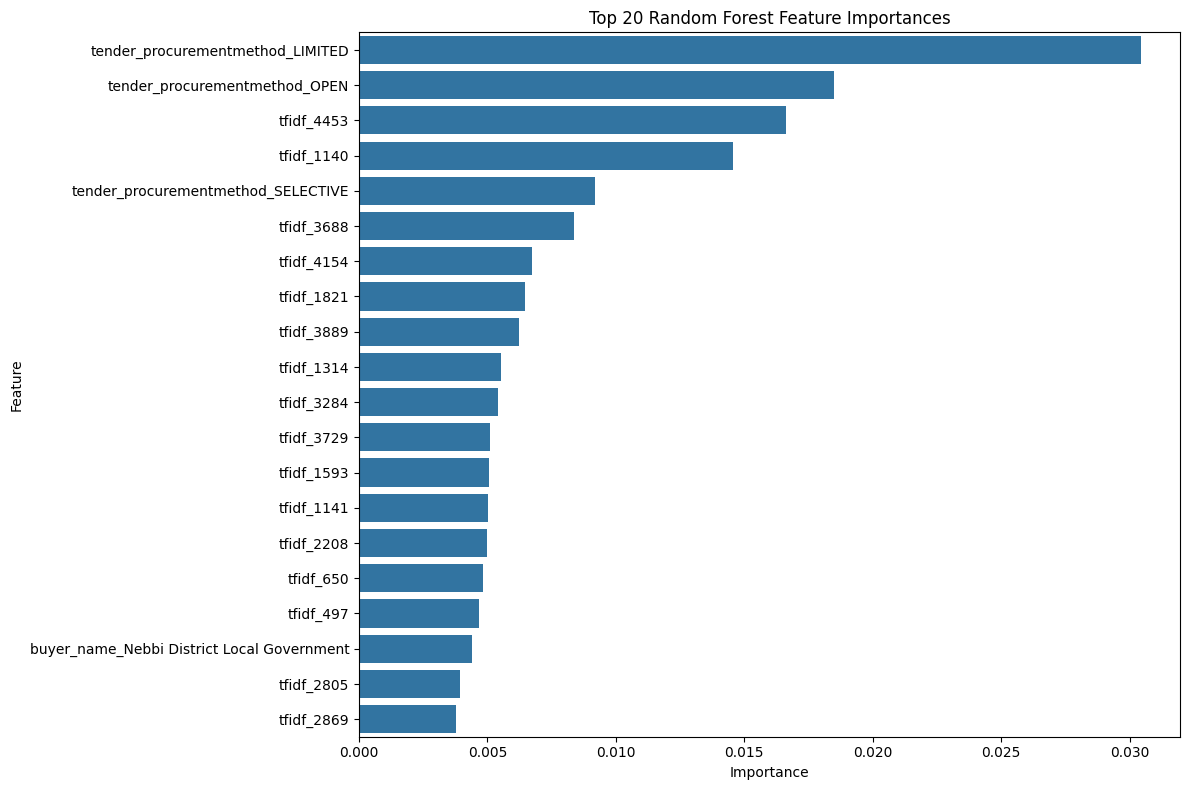

In [ ]:
# Random Forest Feature Importance

# Get feature importance scores from the trained Random Forest model
importances_rf = rf.feature_importances_

# Match them to column names
feature_names_rf = X_train.columns
importance_df_rf = pd.DataFrame({
    'feature': feature_names_rf,
    'importance': importances_rf
}).sort_values(by='importance', ascending=False)

# Display the top 20 most important features
display(importance_df_rf.head(20))

# Plotting feature importance (optional, for better visualization)
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df_rf.head(20))
plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The feature importance plot and table show the relative contribution of each feature to the Random Forest model's predictions. This information can be invaluable for:

*   **Understanding Drivers**: Identifying which aspects of tenders are most indicative of high value.
*   **Feature Engineering**: Guiding further feature creation or refinement efforts.
*   **Business Insights**: Providing actionable insights to procurement stakeholders about critical tender attributes.

## Comparison of Feature Importances: Logistic Regression vs. Random Forest vs. XGBoost

Comparing the feature importances of Logistic Regression, Random Forest, and XGBoost models reveals interesting differences in how each model weighs the predictive power of various features.

### Logistic Regression Observations:
*   **Dominance of TF-IDF Features**: The Logistic Regression model primarily highlights TF-IDF features (e.g., `tfidf_1146`, `tfidf_1147`, `tfidf_1079`) as the most important. This suggests that specific keywords and phrases within the tender titles and descriptions are strong linear indicators for the model in classifying high-value tenders.
*   **Linear Relationship**: Logistic Regression, being a linear model, assigns coefficients directly representing the impact of each feature. The high absolute values for TF-IDF features indicate a strong, direct linear relationship between the presence of certain terms and the likelihood of a tender being high-value.

### Random Forest Observations:
*   **Blend of Feature Types**: The Random Forest model shows a more diversified set of important features. While TF-IDF features still play a significant role, we also see the emergence of one-hot encoded categorical features such as `tender_procurementmethod_LIMITED`, `tender_procurementmethod_OPEN`, and specific `buyer_name` categories (e.g., `buyer_name_Nebbi District Local Government`).
*   **Non-linear Relationships**: As an ensemble of decision trees, Random Forest can capture complex non-linear relationships and interactions between features. This allows it to value combinations of categorical, numerical, and text features, which might not have a simple linear impact.
*   **Categorical Feature Impact**: The higher importance of `tender_procurementmethod` types in Random Forest suggests that the procurement method itself, perhaps through its interaction with other features, is a strong indicator of tender value.

### XGBoost Observations:
*   **Mix of Categorical and TF-IDF**: Similar to Random Forest, XGBoost also identifies a mix of features as important. One-hot encoded features like `tender_procurementmethod_SELECTIVE`, `tender_procurementmethod_LIMITED`, and specific `buyer_name` instances (e.g., `buyer_name_Nebbi District Local Government`, `buyer_name_Tororo District Local Government`) appear high on the importance list, alongside several TF-IDF features.
*   **Tree-based Nuances**: As another tree-based ensemble method, XGBoost excels at capturing complex relationships. Its feature importance (gain, cover, or frequency) indicates how much each feature contributes to the overall model's predictive power. The prominence of specific categorical procurement methods suggests that these discrete choices have a significant, albeit potentially non-linear, impact on tender value.
*   **Fine-grained TF-IDF**: While TF-IDF features are important, XGBoost often highlights different specific TF-IDF terms compared to Logistic Regression, suggesting it leverages different aspects of the textual data in its decision-making process.

### Key Differences and Implications:
1.  **Linear vs. Non-linear Models**: Logistic Regression, constrained by its linearity, primarily relies on individual TF-IDF terms that have a strong, direct correlation. Both Random Forest and XGBoost, being tree-based, can uncover more intricate, non-linear relationships and interactions across a wider array of feature types.
2.  **Feature Emphasis**: While TF-IDF is universally important across all models, Random Forest and XGBoost place a greater emphasis on one-hot encoded categorical features (like procurement method and buyer name) compared to Logistic Regression. This highlights the value of these structural aspects of the tender data when non-linear patterns can be learned.
3.  **Specific Feature Importance**: Even within the TF-IDF features, the specific `tfidf_XXXX` terms that rank highest can differ between models, indicating that each algorithm finds different textual cues most relevant based on its internal mechanics.
4.  **Interpretability**: Logistic Regression offers the most direct interpretability via coefficients. For Random Forest and XGBoost, feature importance provides insight into feature utility but not necessarily the direction of their impact, requiring deeper analysis to understand *how* they influence predictions.

## 5. Model Persistence: Build and Save the Production Pipeline

This section defines and saves the complete machine learning pipeline, including preprocessing steps and the chosen model, to a `.pkl` file for later deployment. The pipeline is fitted on the raw training data to ensure all preprocessing steps are correctly learned.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Create TF-IDF vectorizer
tfidf_pipeline = TfidfVectorizer(max_features=5000, stop_words="english")

# Define categorical columns for the preprocessor
cat_cols_for_preprocessor = [
    "buyer_name",
    "tender_procurementmethod",
    "tender_status"
]

# Create a new RandomForestClassifier instance for the pipeline
pipeline_rf_model = RandomForestClassifier(
    n_estimators=300,        # number of trees
    max_depth=None,         # let trees grow fully
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    class_weight='balanced' # handle imbalance
)

# b. Build full pipeline
full_pipeline = Pipeline([
    ("preprocess", PPDA_Preprocessor(tfidf_pipeline, conversion_rates, cat_cols_for_preprocessor)),
    ("model", pipeline_rf_model) # Use RandomForestClassifier here
])

# c. Fit pipeline on RAW training data
# Reload raw dataset with correct encoding
df_raw = pd.read_csv("/content/drive/MyDrive/PPDA_main.csv", encoding='latin1')

# --- Apply column name cleaning to df_raw after loading ---
# This replicates the cleaning logic from cell M0y_UxXi_Xxu
name_mapping_raw = {}
for col in df_raw.columns:
    if col == '_link':
        name_mapping_raw[col] = 'link'
    elif col == ' tender_value_amount': # Specific fix for this column
        name_mapping_raw[col] = 'tender_value_amount'
    else:
        cleaned_name = (
            col.strip()
            .lower()
            .replace(' ', '_')
            .replace('-', '_')
            .replace('__', '_')
        )
        if col != cleaned_name and col not in name_mapping_raw:
            name_mapping_raw[col] = cleaned_name

if name_mapping_raw:
    df_raw.rename(columns=name_mapping_raw, inplace=True)

# Also apply str[1:] to the 'link' column values if it exists and needs it
if 'link' in df_raw.columns:
    df_raw['link'] = df_raw['link'].astype(str).str[1:]
# --- End of column name cleaning for df_raw ---

# --- Re-apply feature engineering for the target variable on df_raw ---
# This section duplicates the logic from previous cells (WkWR3NP4H5VY, 0TRfNGvzOgRo, sW8nrS4LKEyM)
# to ensure df_raw has the 'high_value_tender' column.

# 1. Convert date columns (needed for tender_duration) and tender_value_amount to numeric on df_raw
date_columns_for_df_raw = [
    'date',
    'tender_bidopening_date',
    'tender_tenderperiod_enddate',
    'tender_tenderperiod_startdate'
]

for col in date_columns_for_df_raw:
    df_raw[col] = pd.to_datetime(df_raw[col], format='%d/%m/%Y', errors='coerce')

# Convert 'tender_value_amount' to numeric on df_raw
df_raw['tender_value_amount'] = df_raw['tender_value_amount'].astype(str).str.replace(',', '').str.strip()
df_raw['tender_value_amount'] = pd.to_numeric(df_raw['tender_value_amount'], errors='coerce')
df_raw['tender_value_amount'] = df_raw['tender_value_amount'].astype('Int64')

# 2. Create tender_value_amount_ugx on df_raw
df_raw["tender_value_amount_ugx"] = df_raw.apply(
    lambda row: row["tender_value_amount"] * conversion_rates.get(row["tender_value_currency"], 1),
    axis=1
)
df_raw["tender_value_amount_ugx"] = pd.to_numeric(df_raw["tender_value_amount_ugx"], errors='coerce')

# 3. Create high_value_tender on df_raw
entity_thresholds_raw = df_raw.groupby("buyer_name")["tender_value_amount_ugx"].quantile(0.75)
df_raw["entity_threshold"] = df_raw["buyer_name"].map(entity_thresholds_raw)
df_raw["high_value_tender"] = df_raw.apply(
    lambda row: "Yes" if row["tender_value_amount_ugx"] >= row["entity_threshold"] else "No",
    axis=1
)
# --- End of re-applied feature engineering for target ---

# Map the target 'high_value_tender' to numerical labels (0 and 1) for RandomForest
y_raw_target = df_raw["high_value_tender"].map({'No': 0, 'Yes': 1})

full_pipeline.fit(df_raw, y_raw_target) # Pass the full raw dataframe and numerical target

# d. Save the unified pipeline
import joblib
joblib.dump(full_pipeline, "/content/drive/MyDrive/ppda_full_pipeline.pkl")
print("Unified PPDA pipeline saved successfully.")

Unified PPDA pipeline saved successfully.


## Prepare Files for Streamlit Deployment (`app.py`, `requirements.txt`, `.gitignore`)

This section generates the necessary files for deploying the prediction model as a Streamlit application. These files will be pushed to GitHub for Streamlit Cloud deployment.

In [ ]:
%%writefile app.py
# -*- coding: utf-8 -*-
"""
PPDA High-Value Tender Prediction — Streamlit App

Run locally:
    streamlit run app.py
    (place ppda_full_pipeline.pkl in this same folder to skip the download)

Run on Streamlit Cloud:
    Push this file + requirements.txt to GitHub, deploy via share.streamlit.io.
    If ppda_full_pipeline.pkl is NOT committed to the repo, the app will
    automatically download it from the Hugging Face Hub repo configured below.
"""

import os
import datetime

import numpy as np
import pandas as pd
import streamlit as st
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from huggingface_hub import hf_hub_download


# Configuration
MODEL_FILENAME = "ppda_full_pipeline.pkl"

# TO DO: set this to the actual Hugging Face Hub repo id, e.g. "Josephine-Analytics/ppda-tender-model"
# Only used if the .pkl is not found locally / not committed to the GitHub repo.
HUGGING_FACE_REPO_ID = "Josephine-Analytics/ppda-tender-value-status-prediction"

st.set_page_config(page_title="PPDA High-Value Tender Prediction", page_icon="💰", layout="wide")

# Custom styling — Uganda-inspired accent palette (black / gold / red)
st.markdown(
    """
    <style>
    :root {
        --ppda-gold: #FCD116;
        --ppda-red: #D90000;
        --ppda-black: #111111;
        --ppda-bg: #F7F4EC;
        --ppda-panel: #FFFFFF;
        --ppda-text: #1F1F1F;
    }

    /* Force light background + dark text everywhere, regardless of browser theme override */
    .stApp {
        background-color: var(--ppda-bg) !important;
    }
    .stApp, .stApp p, .stApp label, .stApp span, .stApp div,
    h1, h2, h3, h4, h5, h6 {
        color: var(--ppda-text) !important;
    }
    section[data-testid="stSidebar"] {
        background-color: #EFEADC !important;
    }
    section[data-testid="stSidebar"] * {
        color: var(--ppda-text) !important;
    }

    /* Input fields — force readable light backgrounds */
    div[data-baseweb="input"] input,
    div[data-baseweb="textarea"] textarea,
    div[data-baseweb="select"] > div,
    div[data-baseweb="base-input"] {
        background-color: var(--ppda-panel) !important;
        color: var(--ppda-text) !important;
        border: 1px solid rgba(0,0,0,0.15) !important;
    }

    .stApp header {background: transparent;}
    div[data-testid="stForm"] {
        border: 1px solid rgba(217, 0, 0, 0.15);
        border-radius: 14px;
        padding: 1.5rem 1.5rem 1rem 1.5rem;
        background: var(--ppda-panel) !important;
    }
    .ppda-hero {
        padding: 1.25rem 1.5rem;
        border-radius: 14px;
        background: linear-gradient(135deg, rgba(252,209,22,0.35), rgba(217,0,0,0.12));
        border: 1px solid rgba(217,0,0,0.15);
        margin-bottom: 1.25rem;
    }
    .ppda-hero h1, .ppda-hero p {
        color: var(--ppda-black) !important;
    }
    .ppda-hero h1 {
        margin: 0;
        font-size: clamp(1.1rem, 2.6vw, 1.8rem);
        white-space: nowrap;
        overflow: hidden;
        text-overflow: ellipsis;
    }
    .ppda-hero p {
        margin: 0.25rem 0 0 0;
        opacity: 0.85;
    }
    div.stButton > button,
    button[kind="formSubmit"],
    div[data-testid="stFormSubmitButton"] button,
    button[data-testid="stFormSubmitButton"],
    div[data-testid="stForm"] button {
        background-color: var(--ppda-red) !important;
        color: #FFFFFF !important;
        border: 1px solid var(--ppda-red) !important;
        border-radius: 8px !important;
        font-weight: 600 !important;
        opacity: 1 !important;
    }
    div.stButton > button *,
    button[kind="formSubmit"] *,
    div[data-testid="stFormSubmitButton"] button *,
    button[data-testid="stFormSubmitButton"] *,
    div[data-testid="stForm"] button * {
        color: #FFFFFF !important;
    }
    div.stButton > button:hover,
    button[kind="formSubmit"]:hover,
    div[data-testid="stFormSubmitButton"] button:hover,
    button[data-testid="stFormSubmitButton"]:hover,
    div[data-testid="stForm"] button:hover {
        background-color: #b30000 !important;
        border: 1px solid #b30000 !important;
        color: #FFFFFF !important;
    }
    div.stButton > button:disabled,
    div[data-testid="stFormSubmitButton"] button:disabled,
    button[data-testid="stFormSubmitButton"]:disabled {
        background-color: #d9a3a3 !important;
        border: 1px solid #d9a3a3 !important;
        color: #FFFFFF !important;
        opacity: 0.7 !important;
    }
    </style>
    """,
    unsafe_allow_html=True,
)

# Preprocessor class — MUST match the class used when the pipeline was
# trained/pickled (same attributes, same transform logic), and must be
# defined here in app.py's own module namespace so joblib can unpickle it.
class PPDA_Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, tfidf_vectorizer, conversion_rates, cat_cols_to_encode):
        self.tfidf = tfidf_vectorizer
        self.conversion_rates = conversion_rates
        self.cat_cols = cat_cols_to_encode
        self.numeric_feature_names = [
            "tender_duration",
            "year",
            "month",
            "quarter",
            "day_of_week",
        ]
        self.ohe_feature_names = None
        self.tfidf_feature_names = None

    def fit(self, X, y=None):
        X_text_combined = X["tender_title"].astype(str) + " " + X["tender_description"].astype(str)
        self.tfidf.fit(X_text_combined)
        self.tfidf_feature_names = [f"tfidf_{i}" for i in range(self.tfidf.idf_.shape[0])]

        temp_ohe_df = pd.get_dummies(X[self.cat_cols], prefix=self.cat_cols)
        self.ohe_feature_names = list(temp_ohe_df.columns)
        return self

    def transform(self, X):
        X_copy = X.copy()

        # 1. tender_value_amount_ugx
        X_copy["tender_value_amount"] = pd.to_numeric(
            X_copy["tender_value_amount"].astype(str).str.replace(",", "").str.strip(),
            errors="coerce",
        ).fillna(0).astype("Int64")

        X_copy["tender_value_amount_ugx"] = X_copy.apply(
            lambda row: row["tender_value_amount"] * self.conversion_rates.get(row["tender_value_currency"], 1),
            axis=1,
        )
        X_copy["tender_value_amount_ugx"] = pd.to_numeric(X_copy["tender_value_amount_ugx"], errors="coerce")

        # 2. tender_duration
        for col in ["tender_tenderperiod_enddate", "tender_tenderperiod_startdate"]:
            X_copy[col] = pd.to_datetime(X_copy[col], format="%d/%m/%Y", errors="coerce")
        X_copy["tender_duration"] = (
            X_copy["tender_tenderperiod_enddate"] - X_copy["tender_tenderperiod_startdate"]
        ).dt.days.fillna(0)

        # 3. Date features
        X_copy["date"] = pd.to_datetime(X_copy["date"], format="%d/%m/%Y", errors="coerce")
        X_copy["year"] = X_copy["date"].dt.year.fillna(0).astype(int)
        X_copy["month"] = X_copy["date"].dt.month.fillna(0).astype(int)
        X_copy["day"] = X_copy["date"].dt.day.fillna(0).astype(int)
        X_copy["day_of_week"] = X_copy["date"].dt.dayofweek.fillna(0).astype(int)
        X_copy["quarter"] = X_copy["date"].dt.quarter.fillna(0).astype(int)

        # 4. Text features (TF-IDF)
        X_text_combined = X_copy["tender_title"].astype(str) + " " + X_copy["tender_description"].astype(str)
        text_features_sparse = self.tfidf.transform(X_text_combined)
        text_features_df = pd.DataFrame(
            text_features_sparse.toarray(), columns=self.tfidf_feature_names, index=X_copy.index
        )

        # 5. One-hot encoding
        ohe_features_df = pd.get_dummies(X_copy[self.cat_cols], prefix=self.cat_cols)
        if self.ohe_feature_names:
            ohe_features_df = ohe_features_df.reindex(columns=self.ohe_feature_names, fill_value=0)

        numeric_features = X_copy[self.numeric_feature_names]

        final_features = pd.concat([numeric_features, ohe_features_df, text_features_df], axis=1)
        final_features = final_features.fillna(0)
        return final_features


# Model loading — local file first, Hugging Face Hub fallback
@st.cache_resource
def load_pipeline():
    model_path = MODEL_FILENAME

    if not os.path.exists(model_path):
        st.info(f"Model file '{MODEL_FILENAME}' not found locally. Downloading from Hugging Face Hub...")
        try:
            model_path = hf_hub_download(repo_id=HUGGING_FACE_REPO_ID, filename=MODEL_FILENAME)
            st.success("Model downloaded successfully.")
        except Exception as e:
            st.error(
                f"Failed to download model from Hugging Face Hub ('{HUGGING_FACE_REPO_ID}'): {e}\n\n"
                "Check that HUGGING_FACE_REPO_ID in app.py is correct and that the repo/file are public "
                "(or that HF auth is configured)."
            )
            st.stop()

    if os.path.getsize(model_path) < 100_000:
        st.error(
            f"Model file at '{model_path}' is only {os.path.getsize(model_path)} bytes — "
            "this looks like a corrupted download or a Git LFS pointer file, not the real model."
        )
        st.stop()

    try:
        return joblib.load(model_path)
    except Exception as e:
        st.error(f"Error loading the pipeline: {e}")
        st.stop()


loaded_pipeline = load_pipeline()

# Streamlit UI
unique_procurement_methods = ["OPEN", "LIMITED", "SELECTIVE", "DIRECT"]
unique_tender_statuses = ["complete", "active"]

st.markdown(
    """
    <div class="ppda-hero">
        <h1>💰 PPDA High-Value Tender Prediction</h1>
        <p>Enter the tender details below to predict <b>High-Value Tender: Yes</b> or <b>No</b>.</p>
    </div>
    """,
    unsafe_allow_html=True,
)

with st.sidebar:
    st.header("⚙️ Configuration")
    st.markdown("Adjust these parameters to customize your prediction.")
    buyer_name = st.text_input(
        "Buyer Name", "Uganda National Roads Authority",
        help="The procuring entity. High-value thresholds are calculated per entity."
    )
    tender_procurementmethod = st.selectbox(
        "Procurement Method", unique_procurement_methods,
        help="OPEN tenders are typically competitive; DIRECT/SELECTIVE are more restricted."
    )
    tender_status = st.selectbox("Tender Status", unique_tender_statuses)

with st.form("tender_prediction_form"):
    st.header("📝 Tender Details")

    col1, col2 = st.columns(2)
    with col1:
        tender_title = st.text_area(
            "Tender Title", "Procurement of Office Supplies",
            height=100,
            help="Short title as it would appear on the tender notice."
        )
        st.caption(
            "💡 **Tip:** Good titles name the works/goods/services and, where "
            "relevant, the location or scope — e.g. *'Rehabilitation of Regional "
            "Highway, Northern Uganda'* rather than just *'Road Works'*. Clearer "
            "titles help the model's text features pick up stronger signals."
        )
    with col2:
        tender_description = st.text_area(
            "Tender Description",
            "Supply and delivery of various office stationery and equipment for the financial year.",
            height=180,
            help="More detail helps the model's text features pick up relevant signals."
        )

    st.subheader("🗓️ Dates")
    with st.expander("View/Edit Tender Dates", expanded=False):
        today = datetime.date.today()
        tender_date = st.date_input("Date", today, help="Publication date — used to derive year/month/quarter features.")
        tender_period_start_date = st.date_input("Tender Period Start Date", today - datetime.timedelta(days=30))
        tender_period_end_date = st.date_input(
            "Tender Period End Date", today + datetime.timedelta(days=60),
            help="Must be after the start date — duration is a key model feature."
        )

    date_error = tender_period_end_date <= tender_period_start_date
    if date_error:
        st.error("🚫 Tender Period End Date must be after the Start Date.")

    st.markdown("---")
    submitted = st.form_submit_button("🚀 Predict High-Value Tender Status", disabled=date_error)

    if submitted:
        input_data = pd.DataFrame(
            {
                "date": [tender_date.strftime("%d/%m/%Y")],
                "buyer_name": [buyer_name],
                "tender_procurementmethod": [tender_procurementmethod],
                "tender_title": [tender_title],
                "tender_description": [tender_description],
                "tender_status": [tender_status],
                # Not used as a model feature (removed to fix target leakage) —
                # kept here only because the preprocessor's transform() still
                # references these columns internally before discarding them.
                "tender_value_amount": [0.0],
                "tender_value_currency": ["UGX"],
                "tender_tenderperiod_enddate": [tender_period_end_date.strftime("%d/%m/%Y")],
                "tender_tenderperiod_startdate": [tender_period_start_date.strftime("%d/%m/%Y")],
                "link": ["dummy_link"],
                "id": ["dummy_id"],
                "tag": ["active"],
                "ocid": ["dummy_ocid"],
                "buyer_id": [9999],
                "tender_id": [99999],
                "tender_bidopening_date": [tender_period_end_date.strftime("%d/%m/%Y")],
                "tender_bidopening_address_streetaddress": ["dummy address"],
                "tender_bidopening_location_description": ["dummy location"],
            }
        )

        try:
            prediction_numerical = loaded_pipeline.predict(input_data)[0]
            prediction_label = "Yes" if prediction_numerical == 1 else "No"

            # Confidence score, if the underlying model supports predict_proba
            proba = None
            try:
                proba = loaded_pipeline.predict_proba(input_data)[0]  # [P(No), P(Yes)]
            except Exception:
                pass

            st.markdown("---")
            result_col, chart_col = st.columns([1, 1])

            with result_col:
                st.markdown("#### High-Value Tender")
                if prediction_label == "Yes":
                    st.success("### 🟢 High-Value Tender: **Yes**")
                    st.info("Consider strategic allocation of resources and closer oversight for this tender. 📈")
                else:
                    st.info("### 🔵 High-Value Tender: **No**")
                    st.caption("Standard procurement handling is likely sufficient. 📊")

                if proba is not None:
                    confidence = proba[1] if prediction_label == "Yes" else proba[0]
                    st.metric("Model Confidence", f"{confidence * 100:.1f}%")
                    st.progress(float(confidence))

            with chart_col:
                if proba is not None:
                    proba_df = pd.DataFrame(
                        {"Outcome": ["High-Value Tender: No", "High-Value Tender: Yes"], "Probability": [proba[0], proba[1]]}
                    ).set_index("Outcome")
                    st.caption("Prediction probability breakdown")
                    st.bar_chart(proba_df, height=220)
                else:
                    st.caption("This model doesn't expose probability scores.")

        except Exception as e:
            st.error(f"An error occurred during prediction: {e}")

Overwriting app.py


In [ ]:
%%writefile requirements.txt
streamlit==1.38.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.1
joblib==1.4.2
xgboost==2.0.3
scipy==1.13.1
huggingface_hub==0.24.6

Overwriting requirements.txt


In [ ]:
%%writefile .gitignore
__pycache__/
.ipynb_checkpoints/
.env
*.log
.streamlit/secrets.toml
ppda_full_pipeline.pkl

Overwriting .gitignore


In [ ]:
%%writefile .streamlit/config.toml
[theme]
base = "light"
backgroundColor = "#F7F4EC"
secondaryBackgroundColor = "#EFEADC"
textColor = "#1F1F1F"
primaryColor = "#D90000"
font = "sans serif"


Overwriting .streamlit/config.toml


## 9. Run the Streamlit App Locally (Optional)

This section allows testing the Streamlit application directly within the Colab environment before deploying it. It will install necessary dependencies and use `localtunnel` to create a publicly accessible URL for the app.

In [ ]:
# Set temporary password for local demo
import urllib.request
print(urllib.request.urlopen('https://loca.lt/mytunnelpassword').read().decode().strip())

34.138.128.219


In [ ]:
import subprocess
import time

# Install all dependencies from requirements.txt
!pip install -r requirements.txt --quiet
!npm install localtunnel --quiet

# start streamlit in the backgroud
process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)
time.sleep(8)  # give Streamlit time to boot
print("Streamlit started.")


#get demo link
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇
up to date, audited 23 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠏Streamlit started.
⠙⠹your url is: https://tidy-trams-jog.loca.lt


## 8. Deploying to Streamlit Cloud

Now that GitHub repository `Josephine-Analytics/ppda-tender-value-status-prediction-app` contains `app.py`, `requirements.txt`, `.gitignore`, and `ppda_full_pipeline.pkl`, the application can now be deployed to Streamlit Cloud.

 [https://share.streamlit.io/](https://share.streamlit.io/).

  **Sign in**: Use GitHub account to sign in.

 **New app**: Click on the "New app" button.

 **Connect repository**: Select GitHub repository `Josephine-Analytics/ppda-tender-value-status-prediction-app`.
 **Main file path**: Ensure the "Main file path" is `app.py`.

**Python version**: Select a compatible Python version (e.g., Python 3.9 or 3.10).

 **Advanced settings (optional)**: If there's need to specify any secrets, you can add them here.

**Deploy**: Click "Deploy!" and wait for application to build and launch.

Streamlit Cloud will automatically install the dependencies listed in `requirements.txt` and run your `app.py` file. Once deployed, you will get a public URL for your application.